# RF vs. Bayes Optimization
A series of experiments comparing a Random Forest and Bayes Optimization w/ a GP in an "online" scenario. Using existing data, I will feed the RF and BayesOpt new points (random or from acquisiton function) and re-evaluate the $ R^2$ score.  

## Dataset initialization

In [39]:
import sys
import os
import time
sys.path.append(os.path.abspath('..'))
from venus_ml import VenusDataset

In [40]:
config = {
    "file_path": "../data/acc_watch_data.parquet",
    "input_columns": ["inj_mbar_mean", "bias_v_mean", "bias_i_mean", "extraction_i_mean", "ext_mbar_mean", "k18_fw_mean", "g28_fw_mean", "puller_i_mean"],
    "output_columns": ["fcv1_i_mean"],
}

dataset = VenusDataset(**config)
df = dataset.df
print(df['run_id'].unique())

['00' '01' '02' '03' '04' '05' '06' '08' '08a' '08b' '08c' '08d' '09' '10'
 '10b' '11' '11b' '12' '13' '14']


In [41]:
import pandas as pd

def get_run_data(df: pd.DataFrame, run_id_value) -> pd.DataFrame:
    """
    Returns a subset of the dataframe for which the 'run_id' column matches the given run_id_value.
    """
    return df[df['run_id'] == run_id_value].copy()


def select_features(df: pd.DataFrame, input_columns: list, output_column: str) -> pd.DataFrame:
    """
    Returns a dataframe containing only the specified input columns and the output column.
    """
    return df[input_columns + [output_column]].copy()


## Plotting

In [42]:
import matplotlib.pyplot as plt

def plot_r2_curves(r2_rf: list, r2_gp: list, title: str = "R² vs. Iteration", x_label: str = "Iteration", y_label: str = "R² Score"):
    """
    Plots two curves of R² values from Random Forest (RF) and Gaussian Process (GP) models.
    """
    plt.figure(figsize=(10, 6))
    iterations_rf = range(1, len(r2_rf) + 1)
    iterations_gp = range(1, len(r2_gp) + 1)
    
    plt.plot(iterations_rf, r2_rf, marker='o', linestyle='-', color='blue', label='Random Forest')
    plt.plot(iterations_gp, r2_gp, marker='s', linestyle='--', color='red', label='Gaussian Process')
    
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Experiment 1: Random Forest R^2 vs. Training Set Size w/ Random Point Selection


In [43]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
from tqdm import tqdm

def run_rf_experiments(df: pd.DataFrame, run_ids: list, input_columns: list, output_column: str, 
                       start_points: int = 1, step: int = 1, validation_size: float = 0.2, n_trials: int = 5) -> dict:
    """
    For each run in run_ids, iteratively trains a RandomForestRegressor.
    For each run, performs n_trials experiments (with a different shuffle each time).
    In each trial, the data is split into a training set and a fixed validation set.
    Then, starting with a training subset of 'start_points' and increasing by 'step' points,
    the model is trained and R² is computed on the fixed validation set.
    
    Returns a dictionary where:
        results[run_id][i] is a list of n_trials R² scores obtained when training on i points.
    """
    results = {}
    
    for run_id in run_ids:
        print(f"Starting run {run_id}...")
        # Use the full run data without initial shuffling since we'll re-shuffle per trial.
        run_df = get_run_data(df, run_id)
        run_results = {}  # Keys will be training size, values a list of R² scores (length = n_trials)
        
        # Repeat the experiment n_trials times.
        for trial in range(n_trials):
            # Re-shuffle the run_df with a different random seed for each trial.
            trial_run_df = run_df.sample(frac=1, random_state=trial).reset_index(drop=True)
            # Split into training and validation sets for this trial.
            train_df, val_df = train_test_split(trial_run_df, test_size=validation_size, random_state=trial)
            train_df = train_df.reset_index(drop=True)
            val_df = val_df.reset_index(drop=True)
            
            n_train_points = train_df.shape[0]
            
            # Iterate through increasing training sizes.
            for i in tqdm(range(start_points, n_train_points, step), 
                          desc=f"Run {run_id}, Trial {trial+1}: Training points", unit="pt"):
                current_train_df = train_df.iloc[:i]
                
                # If the validation set is too small, use the last computed R² value (or 0.0)
                if val_df.shape[0] < 2:
                    r2_val = run_results.get(i, [0.0])[-1]
                else:
                    X_train = current_train_df[input_columns]
                    y_train = current_train_df[output_column]
                    X_val = val_df[input_columns]
                    y_val = val_df[output_column]
                    
                    # Fit the RandomForestRegressor.
                    rf = RandomForestRegressor(n_estimators=150, n_jobs=-1)
                    rf.fit(X_train, y_train)
                    y_pred = rf.predict(X_val)
                    r2_val = r2_score(y_val, y_pred)
                
                # Store the R² value for this training size.
                if i not in run_results:
                    run_results[i] = []
                run_results[i].append(r2_val)
        
        # After all trials for a run, store the results.
        results[run_id] = run_results
        print("\n")
    return results


In [44]:
run_ids = ['00', '01', '02', '08a', '08b', '08c', '08d', '09', '11', '11b', '12', '13']
input_cols = ["inj_mbar_mean", "bias_v_mean", "bias_i_mean", "extraction_i_mean",
              "ext_mbar_mean", "k18_fw_mean", "k18_ref_mean", "g28_fw_mean", "puller_i_mean"]
output_col = "fcv1_i_mean"

results = run_rf_experiments(df, run_ids, input_cols, output_col, start_points=1, step=10, n_trials=3)

Starting run 00...


Run 00, Trial 3: Training points: 100%|██████████| 204/204 [00:21<00:00,  9.49pt/s]




Starting run 01...


Run 01, Trial 3: Training points: 100%|██████████| 57/57 [00:05<00:00, 11.22pt/s]




Starting run 02...


...

Run 11b, Trial 3: Training points: 100%|██████████| 149/149 [00:15<00:00,  9.65pt/s]




Starting run 12...


Run 12, Trial 3: Training points: 100%|██████████| 130/130 [00:13<00:00,  9.70pt/s]




Starting run 13...


Run 13, Trial 3: Training points: 100%|██████████| 95/95 [00:09<00:00, 10.24pt/s]

In [45]:
import matplotlib.pyplot as plt
import numpy as np

def plot_rf_results(results_dict: dict):
    """
    Plots R² vs. number of training points for each run in results_dict.
    For each run, 5 trials are plotted (one per curve) in different colors.
    Each trial's curve has a star marker at the first point where R² ≥ 0.9.
    The subplot title also mentions the average number of training points required to reach R² ≥ 0.9.
    
    The results_dict structure is assumed to be:
        results_dict[run_id][training_size] = list of R² scores for each trial.
    """
    n_runs = len(results_dict)
    # Create subplots: one per run.
    fig, axes = plt.subplots(n_runs, 1, figsize=(8, 4 * n_runs), sharey=False)
    if n_runs == 1:
        axes = [axes]  # Ensure axes is iterable for a single run
    
    for ax, (run_id, run_results) in zip(axes, results_dict.items()):
        # run_results: keys are training sizes; values are lists of R² scores (length = n_trials)
        training_sizes = sorted(run_results.keys())
        n_trials = len(next(iter(run_results.values())))
        # Create a color map for the n_trials curves.
        colors = plt.cm.tab10(np.linspace(0, 1, n_trials))
        
        # For storing the training size at which each trial reaches R² >= 0.9
        reached_points = []
        
        # Plot each trial's results.
        for trial in range(n_trials):
            trial_r2 = [run_results[size][trial] for size in training_sizes]
            ax.plot(training_sizes, trial_r2, linestyle='-', color=colors[trial],
                    label=f'Trial {trial+1}')
            
            # Find the first training size where R² >= 0.9 for this trial.
            reached = None
            for size, r2 in zip(training_sizes, trial_r2):
                if r2 >= 0.9:
                    reached = size
                    break
            if reached is not None:
                reached_points.append(reached)
                # Mark that point with a star.
                ax.plot(reached, 0.9, marker='*', markersize=12, color=colors[trial],
                        label=f'R²≥0.9 at {reached} pts (Trial {trial+1})')
        
        # Calculate the average number of points needed to reach R² ≥ 0.9, if available.
        if reached_points:
            avg_points = np.mean(reached_points)
            title_str = f'Run {run_id} (Avg pts for R²≥0.9: {avg_points:.1f})'
        else:
            title_str = f'Run {run_id} (No trial reached R²≥0.9)'
        
        ax.set_title(title_str)
        ax.set_xlabel('Number of Training Points')
        ax.set_ylabel('R² Score')
        ax.grid(True)
        ax.legend()
    
    plt.tight_layout()
    plt.show()


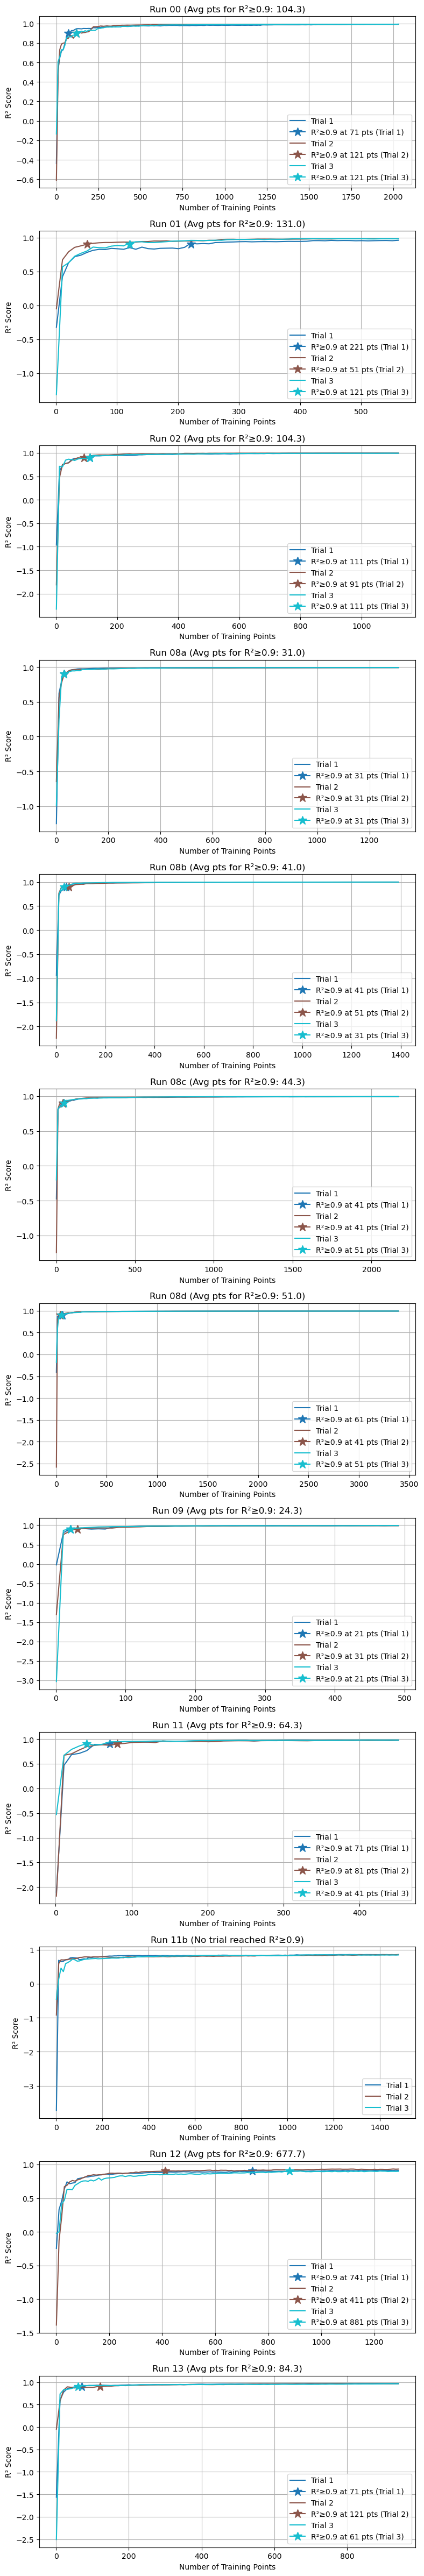

In [46]:
plot_rf_results(results)